## Example 3: Large Geology Model Generation

This example demonstrates the use of **ModGen2D** to generate a **large-scale geological model** with complex subsurface features and controlled stochastic variability.

In this notebook, we will:

- Generate a **fixed stratigraphic framework** with surface topography and multiple lithological layers.
- Incorporate **multiple obstruction categories simultaneously**, including shallow utilities and **user-defined** complex karst geometries.
- Demonstrate how to define and use a **user-defined obstruction2d** class.
- Produce **multiple stochastic realizations** by resimulating material properties while keeping the geological structure unchanged.
- Demonstrate **selective property overriding**, such as enforcing competent rock conditions in the bottom layer, with built-in validation to prevent physically inconsistent configurations.

This example highlights how ModGen2D can be used to efficiently create **reproducible, geotechnical-scale models** suitable for uncertainty quantification and large ensemble generation.


In [1]:
import pandas as pd
import numpy as np
import modgen2d as mg2d
import example3_helper_functions as hf

## Step 1: Length Configuration

Define how lengths are represented internally and externally.

- **`physical_length_unit`** (`str`)  
  - Unit used **externally** by the user (e.g., `'m'`).  
  - Represents the **real-world scale** and is used throughout for input/output.

- **`Resolution`**
    - Provide one of:
        - min_dl: Smallest allowed length (must be 10^(integer))
        - max_grid_density: Units per physical length (must be 10^(integer)) and is inverse of min_dl

- **`domain_units (Internal)`** (`str`)  
  - Discretized integer-based units used  **internally** for computation.

In [2]:
length_config = mg2d.LengthConfig("m", max_grid_density=100) 

## Step 2: Properties Definition

In this step, we define the **features and their properties** within the domain.  

Properties can become as complex as needed, depending on:

- The number of **feature types** (e.g., soil, utilities, karst)
- The number of sub-types of each features.
- Conditions of the features (e.g., wet/dry soils)
- Type of random generators for each feature (Uniform, Constant etc.)

For simplicity, this example splits Step 2 into **four sub-steps**:

1. **General Definitions** – basic setup and parameters.  
2. **Feature Configuration** – define which materials belong to which features.  
3. **Main Properties** – assign physical properties like density, velocity, etc.  
4. **Auxiliary Properties** – any extra properties needed for modeling.

### Step2.1: General Definitions

In [28]:
# Domain dimensions
x_span = 50          # Domain length in X-direction (domain units)
z_span = 30          # Domain depth in Z-direction (domain units)

# Grid spacing
del_xz_interface = 1       # Base spacing for the interfaces (Note: for Unifrom, too small dx might make interface flat)
# del_xz_spatial = 0.5    # Base spacing for the domain for soil domain (spatial correlation): spatial correlation is a computationally heavy.
del_xz_final = 0.5       # Base spacing for the domain for obstacles and final generated model.

del_xz_obs = 0.1  # Finer spacing for obstacles (recommended: 1/10)

# Interface interpolation method
remesh_interp_method = 'linear'

# Spatial correlation parameters
spatial_theta_x = 100  # Correlation length in X
spatial_theta_z = 0.5  # Correlation length in Z

# Random number generator (for reproducibility)
rng = np.random.default_rng(seed=42)

### Step 2.2: Features Configuration

In [29]:
# Initialize feature configuration
feature_config_instance =  mg2d.FeaturesConfig()

# Define material distributions for this simple example
# For this example, there are only one material type for soil - "generic soil", utilities - "PVC", and karst - "voids". 
# Note: these distributions must be random_generators: Hence, using "Constant".
soil_materials_distribution = mg2d.random_generators.Constant(val = 'soil', rng=rng)
utils_materials_distribution = mg2d.random_generators.Constant(val = 'PVC', rng=rng)
karst_materials_distribution = mg2d.random_generators.Constant(val = 'void', rng=rng)

# Add features to feature_config_instance
feature_config_instance.add_feature('def', soil_materials_distribution, feature_description = 'def means soil.')
feature_config_instance.add_feature('U', utils_materials_distribution, feature_description = 'utility features')
feature_config_instance.add_feature('K', karst_materials_distribution, feature_description = 'karst: Void in soils')

### Step 2.3: Main Properties

In this step, we define **main physical properties** for each feature in the domain (e.g., shear wave velocity `vs`).
Main property refers to all the properties that is to be "simulated".

Each property can have different values for wet and dry conditions. 
- **Wet / Both conditions**  - If dry condition is not provided (is None), then it refers to "both". ie (wet and dry condition are same)
- **Dry conditions** (optional)  

We also define **layer0 values**, which represent property values of **water if wet; air if dry**; needed if the model has a **non-horizontal ground surface**, so layer0 properties are applied accordingly.

In [30]:
#2.3.1 Main Properties config definition
main_properties_config_instance =  mg2d.MainPropertiesConfig(feature_config_instance, layer0_flag=True)

#2.3.2 Define each MainProperty instance
main_property_name = 'vs'
property_desc = 'shear wave velocity'
main_property_instance = mg2d.MainProperty(main_property_name, feature_config_instance, layer0_flag=True, description=property_desc)

#2.3.3  Define wet and dry properties for each features' each materials (including layer 0  for 'def' if flag is True)
## For Feature 'def'; material type 'soil'
wet_mean_distribution = mg2d.random_generators.Uniform(80, 900, rng)  
cov_distribution = mg2d.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = mg2d.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)

dry_prop = None     # If None, GWT does not matter for this material's property (of interest).
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='soil', #Must match feature_id and material name (as defined in features_config)
                                                        property_distribution_instance=wet_prop,  
                                                        property_distribution_instance_if_dry=dry_prop 
                                                       )

## For Feature 'def'; material type 'layer0'
wet_mean_distribution = mg2d.random_generators.Constant(10, rng)  
cov_distribution = None  # None means 'cov' is 0 (i.e. no spatial correlation)
cov_type = 'cov'
wet_prop = mg2d.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)

dry_prop = None
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='layer0', 
                                                        property_distribution_instance=wet_prop,
                                                        property_distribution_instance_if_dry=dry_prop)


## For Feature 'utils'; material type 'PVC'
wet_mean_distribution = mg2d.random_generators.Uniform(1140, 1750, rng)  
cov_distribution = None    # None means cov/stdev is 0 (i.e. no spatial correlation)
cov_type = 'cov'
wet_prop = mg2d.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)

dry_prop = None
main_property_instance.add_material_property_of_feature(feature_id='U', material_name='PVC',
                                                        property_distribution_instance=wet_prop, 
                                                        property_distribution_instance_if_dry=dry_prop)

## For Feature 'karst'; material type 'void'
wet_mean_distribution = mg2d.random_generators.Constant(10, rng)  
cov_distribution = None
cov_type = 'cov'
wet_prop = mg2d.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = None
main_property_instance.add_material_property_of_feature(feature_id='K', material_name='void', 
                                                        property_distribution_instance=wet_prop, 
                                                        property_distribution_instance_if_dry=dry_prop)

# 2.3.4 Add MainProperty to MainPropertiesConfig instance
main_properties_config_instance.add_main_property(main_property_instance)

main_properties_config_instance.print()

Main_Properties: ['vs']
feature_ids: ['def', 'U', 'K']
---------------------------
Property Name: vs
Description: shear wave velocity
All Feature IDs: ['def', 'U', 'K']
Properties:
{'def': {'soil': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x0000020B1010D4E0>},
         'layer0': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x0000020B1010D420>}},
 'U': {'PVC': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x0000020B1010D480>}},
 'K': {'void': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x0000020B1010D3C0>}}}


### Step 2.4: Auxiliary Properties

Auxiliary properties are not simulated directly but are required for model generation like number of soil layers, etc.
Think of auxiliary properties as a collection of random generators or configuration values that support the simulation.

You can define them using a dictionary too.

In [31]:
# Define some additional Properties
aux_props = mg2d.AuxillaryProperties()
aux_props.add_aux_property('n_layers',  mg2d.random_generators.DiscreteChoice(x=[3,4,5,6,7,8,9,10,11,12], p=[0.05,0.08,0.1,0.1,0.1,0.1,0.1,0.1,0.12,0.15], rng=rng))
aux_props.add_aux_property('rock_vs_mean',  mg2d.random_generators.Uniform(1200, 2500, rng))
aux_props.add_aux_property('gwt', mg2d.random_generators.Uniform(0, 30, rng))

utilities_sett={
    'n_obs': mg2d.random_generators.DiscreteChoice([0,1,2,3,4,5,6,7], rng=rng),
    'obs_shape': mg2d.random_generators.DiscreteChoice(['circ2d', 'rect2d',], [1/2, 1/2], rng=rng),
    'dia_obs':mg2d.random_generators.Uniform(1, 3, rng=rng), 
    'lh_obs':mg2d.random_generators.Uniform(1, 3, rng=rng), 
    'obs_x_coord':mg2d.random_generators.Uniform(0, x_span, rng=rng), 
    'depth_top_dist':mg2d.random_generators.Uniform(0, 5, rng=rng), 
}

karst_sett={
    'n_karst': mg2d.random_generators.DiscreteChoice([0,1,2], rng=rng),
    'karst_size':mg2d.random_generators.Uniform(2, 7, rng=rng), 
    'karst_x_coord':mg2d.random_generators.Uniform(0, x_span, rng=rng), 
    'karst_depth_top_dist':mg2d.random_generators.Uniform(5, 30, rng=rng), 

    # Making prob. of karst at larger depth more than that in shallower depth.
    #Continuous distribution: discrete to be converted into continuous: also
    'karst_depth_top_dist':hf.Discrete2ContinuousPDF([5,30], p = [.2,1], new_del_x = 1, rng=rng), 
    
}

aux_props.add_aux_property('n_obs', utilities_sett['n_obs'])
aux_props.add_aux_property('obs_shape', utilities_sett['obs_shape'])
aux_props.add_aux_property('dia_obs', utilities_sett['dia_obs'])
aux_props.add_aux_property('lh_obs', utilities_sett['lh_obs'])
aux_props.add_aux_property('obs_x_coord', utilities_sett['obs_x_coord'])
aux_props.add_aux_property('depth_top_utils', utilities_sett['depth_top_dist'])


aux_props.add_aux_property('n_karst', karst_sett['n_karst'])
aux_props.add_aux_property('karst_size', karst_sett['karst_size'])
aux_props.add_aux_property('karst_x_coord', karst_sett['karst_x_coord'])
aux_props.add_aux_property('karst_depth_top_dist', karst_sett['karst_depth_top_dist'])
aux_props.print()

Additional_Properties: dict_keys(['n_layers', 'rock_vs_mean', 'gwt', 'n_obs', 'obs_shape', 'dia_obs', 'lh_obs', 'obs_x_coord', 'depth_top_utils', 'n_karst', 'karst_size', 'karst_x_coord', 'karst_depth_top_dist'])


## Step 3: Model Definition

In this step, we define the computation **domain2d**, **geological interfaces**, **2D lithological model**, and simulation of **generated model2d**.
This step connects everything defined earlier (units, features, properties) into an actual **2D subsurface model**.

### Step 3.1: 2D Domain Definition

The domain defines the **size and resolution** of the model grid.

In [32]:
domain_interface = mg2d.DiscretizedDomain2D(x_span, z_span, del_xz_interface, del_xz_interface, length_config)
domain_final = mg2d.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, length_config)

### Step3.2: Interface Definitions

Interfaces define the layer boundaries (e.g., soil layers, ground surface). 

Here, unlike previous examples, we have used the **`DiscretizedInterfaces2D`** class directly.  This approach provides **more direct control** and is **more powerful for complex workflows**, but it requires manual setup of multiple steps and can be more cumbersome. An easier and simpler alternative is to define interfaces using **DiscretizedInterfaces2DFromDict**.

This approach makes it easy to experiment with different geological scenarios while keeping the model setup clean and reproducible.

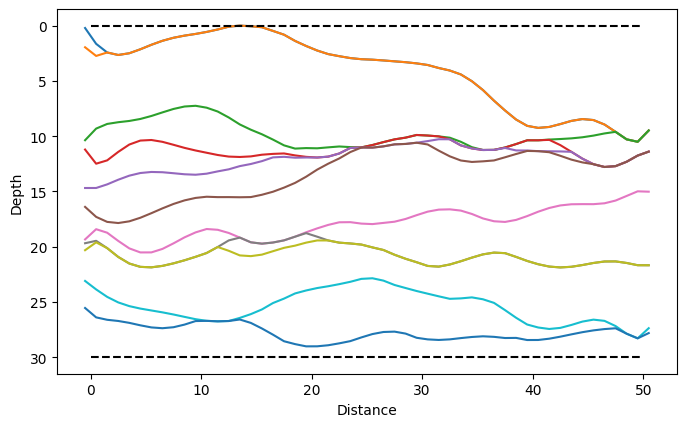

In [33]:
n_layers = aux_props.aux_properties['n_layers'].generate()
gwt_depth = aux_props.aux_properties['gwt'].generate()

roughness_multipliers = [1.5,1.3,1.2,1]
# If number of layers > length of list, last value is reused

# DiscretizedInterfaces2D from dictionary definition
soil_interface = mg2d.interface.DiscretizedInterfaces2D(domain_interface, n_layers, generate_surface=True,
                                            remesh_interp_method=remesh_interp_method, 
                                            rng=rng)

# Generation of rough interfaces
rough_interface_generator = mg2d.interface.rough_interface_generator.UniformInterfaceGen(1, generate_surface=True, roughness_multipliers=roughness_multipliers)
smoother = mg2d.interface.interface_smoother.SavGol2DSmoother(filter_window_length = 21, filter_polyorder = 7)
depth_updater = mg2d.interface.depth_updaters.RandomDepthUpdater(ref_x=None)

# .apply auto detects the type of object/command
soil_interface.apply(rough_interface_generator)

# Can do chains of commands (Note, each apply means each step)
soil_interface.apply(smoother).apply(depth_updater)

# For overlapping resolution, use command as string (either 'erosion', or 'reverse_erosion'). 
soil_interface.apply('erosion')
# Same as using soil_interface.resolving_overlapped_interfaces(overlap_resolving_technique='erosion')


# Similarly for surface adjustment to make sure top of surface is zero. use string 'adjust_surface_top_to_zero'
soil_interface.apply('adjust_surface_top_to_zero')
#Or, soil_interface.adjust_top_of_surface_interface_to_zero()

soil_interface.plot()
soil_interface.lock_interfaces()

<Axes: xlabel='Distance', ylabel='Depth'>

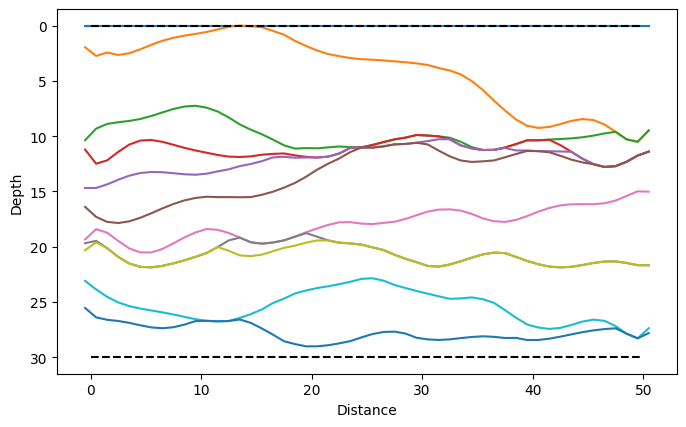

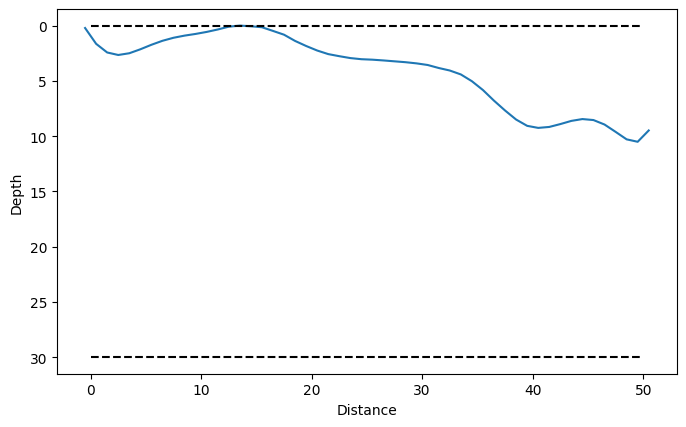

In [34]:
# To visualize and see surface and subsurface interfaces.
a,b = soil_interface.get_surface_and_subsurface_interfaces()
a.lock_interfaces()
b.lock_interfaces()
a.plot()
b.plot()

### Step 3.3: Lithological Domain (2D) Definition  
#### Step 3.3.1: From Interfaces (Global Soil Interface Configuration)

In this section, we first set and fix a global soil interface configuration.  
This global configuration is used internally and checked later to ensure the interface has not changed.

Important: For a single model, the global soil interface configuration must remain consistent throughout the workflow.

Once the global interface is fixed, we use a simple helper function to generate the 2D lithological domain directly from this global configuration.


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

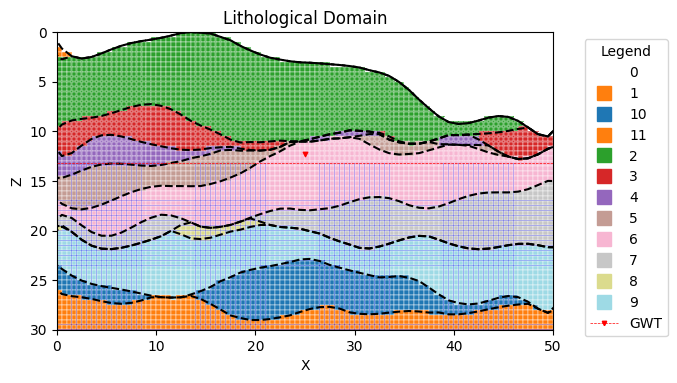

In [35]:
# Reset global soil interface configuration (safety step)
mg2d.GlobalSoilInterfaceConfig.reset()   # For safety only

# Register soil interface
mg2d.GlobalSoilInterfaceConfig.set_soil_interface(soil_interface)

## Get lithological domain from interface
name = 'soil_lit'
lit = mg2d.LithologicalDomain2D(domain_final, gwt_depth, name)
lit.plot(discrete_point_size = 10, plot_interfaces=True)

#### Step 3.3.2: From Obstruction2D (Global Soil Interface Configuration)

In this section, we first initialize a **`LithologicalDomain2DFromObstruction2D`** instance, which will be used to incrementally construct the lithological domain.  
For each subsurface feature, an obstruction is defined using the **`Obstruction2D`** class.

Random generators may be used to define the required parameters, such as the shape, size, and other geometric properties of the obstructions (if applicable).

Once an obstruction is defined, it is added to the previously initialized `LithologicalDomain2DFromObstruction2D` instance to update the lithological domain.


In [36]:
mg2d.GlobalSoilInterfaceConfig.get_interface_instance().get_surface_and_subsurface_interfaces()

(<modgen2d.interface._read_only.DiscretizedInterfaces2DReadOnly at 0x20b0f7d46e0>,
 <modgen2d.interface._read_only.DiscretizedInterfaces2DReadOnly at 0x20b1796a720>)

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

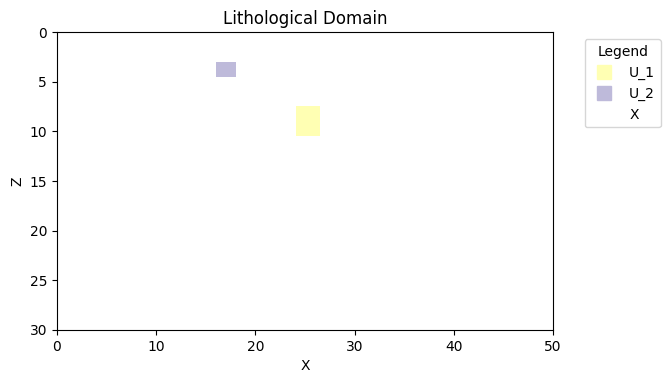

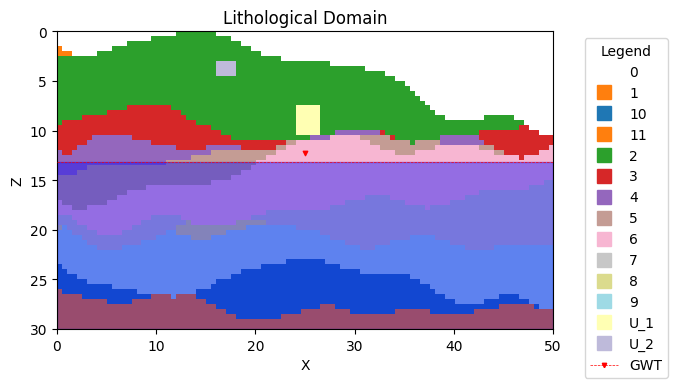

In [37]:
## Define a LithologicalDoamin2d From obstruction 2d.
obs_lit = mg2d.LithologicalDomain2DFromObstruction2D(domain_final, 'obstructions')

# Number of obstructions to generate
n_obs = 2; #aux_props.aux_properties['n_obs'].generate()

# Randomly generate obstruction shapes
obs_shapes = aux_props.aux_properties['obs_shape'].generate((n_obs,))

# For each obstruction, create a Obstruction2D instance first, and then add to obs_lit. 
for i, obs_shape in enumerate(obs_shapes):
    # Generate obstruction location
    obs_x_coord = aux_props.aux_properties['obs_x_coord'].generate()
    d_obs = aux_props.aux_properties['depth_top_utils'].generate()

    # Unique obstruction ID
    obs_id = i+1

    # Initialize Obstruction2D object
    obs_instance = mg2d.Obstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)

    # Define obstruction geometry
    if obs_shape == 'circ2d':
        d = aux_props.aux_properties['dia_obs'].generate()
        obs_instance.circle_2d(d, obstruction_id = obs_id)
    elif obs_shape == 'rect2d':
        lx = aux_props.aux_properties['lh_obs'].generate()
        lz = aux_props.aux_properties['lh_obs'].generate()
        obs_instance.rectangle_2d(lx, lz, obstruction_id = obs_id)
    else:
        raise ValueError(f"Invalid util_shape {obs_shape}")
    # obs_instance.plot()

    ## Add Obs2D into defnined lit_domain_from_obs2d 
    obs_lit.add_obstruction2D(obs_instance, shift_ref2d_to_xy = [obs_x_coord, d_obs], feature_id='U')

# Plot lithological domain generated from obstructions (JUST FOR VISUALIZATION)
obs_lit.plot()


# Visualize merged lithological domain (JUST FOR VISUALIZATION)
merged_lit = lit.return_merged_lithological_domain([obs_lit])  # Just to see how merged lit. Karst to be added later.
merged_lit.plot()


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\_plots.py:285: UserWarning: Warning: Some feature_ids of lithological ids in the plot were not found, and used random colors for them. Use color_map argument for consistent colors.
  warnings.warn("Warning: Some feature_ids of lithological ids in the plot were not found, and used random colors for them. Use color_map argument for consistent colors.")


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

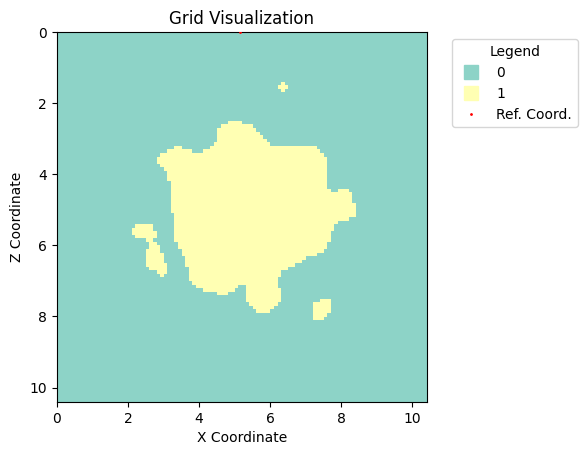

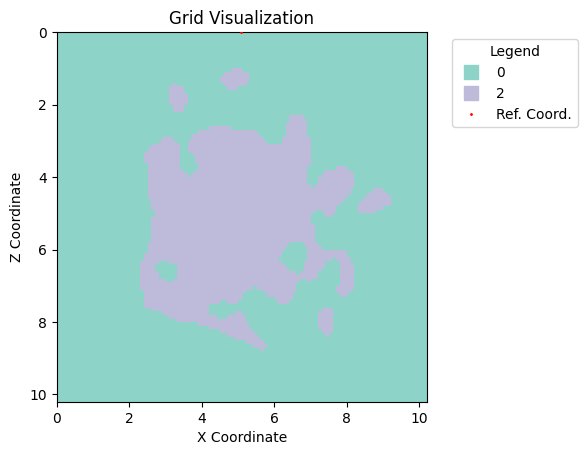

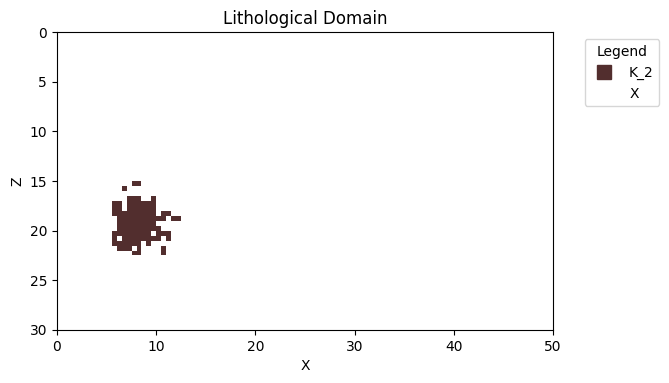

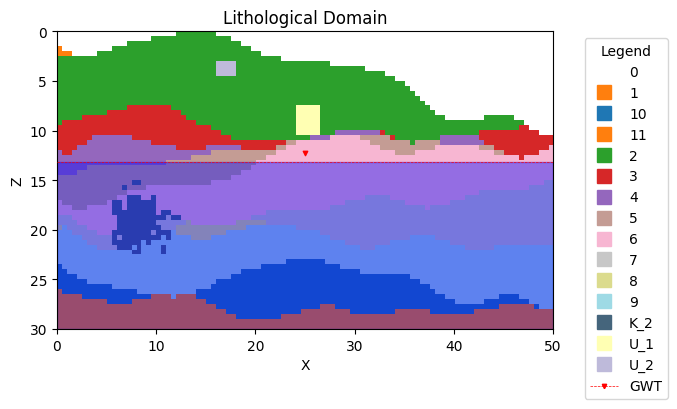

In [38]:
# Do similar for Karsts.

## Define a LithologicalDoamin2d From obstruction 2d.
karst_lit = mg2d.LithologicalDomain2DFromObstruction2D(domain_final, 'karst')

# Number of obstructions to generate
n_karst = 2; #aux_props.aux_properties['n_karst'].generate()

# For each obstruction, create a Obstruction2D instance first, and then add to obs_lit. 
for i in range(n_karst):
    # Generate obstruction location
    karst_x_coord = aux_props.aux_properties['karst_x_coord'].generate()
    d_obs = aux_props.aux_properties['karst_depth_top_dist'].generate()

    # Unique obstruction ID
    obs_id = i+1

    # Initialize Obstruction2D object
    karst_instance = hf.ManualObstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)

    # Define obstruction geometry
    d = aux_props.aux_properties['karst_size'].generate()
    karst_instance.karst_circle_perlin(d, noise_amplitude=1., smooth_sigma=3.0, obstruction_id=obs_id, rng=rng)
    karst_instance.plot()
    
    ## Add Obs2D into defnined lit_domain_from_obs2d 
    karst_lit.add_obstruction2D(karst_instance, shift_ref2d_to_xy = [karst_x_coord, d_obs], feature_id='K')

# Plot lithological domain generated from obstructions (JUST FOR VISUALIZATION)
karst_lit.plot()

# Visualize merged lithological domain (w/ both obs and karst) (JUST FOR VISUALIZATION)
merged_lit = lit.return_merged_lithological_domain([obs_lit, karst_lit])
merged_lit.plot()


### Step 3.4: Lithological Domain Collection

In this step, we combine multiple lithological domains (e.g., soil layers, karst features, utilities) into a single **lithological domain collection** class instance.

The `LithologicalDomain2DCollection` class:
- Acts as a **container** for all lithological domains used in the model
- Ensures **feature consistency** across domains
- Controls **merging order and validation**
- Prevents accidental modification once finalized

The collection is initialized using the list of feature IDs defined in the main properties configuration.  
The `interface_set_name` identifies the soil interface configuration used as the global reference.


In [39]:
# Initialize lithological domain collection
lit_collection = mg2d.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 

# Add soil-based lithological domain
lit_collection.add_lithological_domain_from_soil_interface_config(lit)

# Add other obstruction-based lithological domain (Note priority to later added obstructions in case of overlapping
lit_collection.add_lithological_domain_from_obstruction2d("obs", obs_lit)
lit_collection.add_lithological_domain_from_obstruction2d("karst", karst_lit)

# Finalize and lock the lithological domain collection
lit_collection.lock()


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\lithological_domain2d\a_from_interface.py:128: UserWarning: The current lit domain was created with merging a domain with soil lit domain. That merging domain is lost/ignored on returned lit domain.
  warnings.warn("The current lit domain was created with merging a domain with soil lit domain. That merging domain is lost/ignored on returned lit domain.")


### Step 4: Generate Simulated Property Profiles

For this example, we will generate **multiple realizations of the main property profiles** (`vs`) across the lithological domain.  

Key points "For this example":  
- Each realization uses the **same lithological domain and property distributions**.  
- The **spatial pattern varies** due to the spatial simulator, demonstrating variability in property fields.  
- We also manually override the top layer (`rock`) properties for this example.


In [40]:
# Dictionary to store generated profiles
all_profiles = {}

# Generate 10 different spatial realizations
for i in range(10):
    
    # Unlock main properties config to allow sampling
    main_properties_config_instance.unlock()

    # Sample property values for all features in the lithological domain
    main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)
    sample_properties = main_properties_config_instance.sampled_properties
    
    # Override top rock layer ('layer0') property for demonstration
    rock_vs_mean = aux_props.aux_properties['rock_vs_mean'].generate()
    sample_properties['vs'][f'{n_layers}']['both']['mean'] = rock_vs_mean
    sample_properties['vs'][f'{n_layers}']['both']['stdev/cov'] = 0

    
    # Update the sampled properties in the config
    main_properties_config_instance._sampled_properties = sample_properties

    # Initialize spatial simulator (controls spatial correlation)
    spatial_sim = mg2d.spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng = rng)

    # Generate property profiles using the spatial simulator
    gen_profiles = mg2d.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
    gen_profiles.simulate_property_profile('vs')        
    all_profiles[i] = gen_profiles

    #Save the profiles into h5 files
    gen_profiles.save_to_hdf5(f'generated_h5_files/{i:08d}.h5', hdf5_compression_level=8)

Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 10
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 11
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 6
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 7
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 8
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 9
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: K_2
Simulating z-vals for Layer ID: X


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer 0: sigma=0 but 811 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_2: sigma=0 but 12 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_1: sigma=0 but 30 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer K_2: sigma=0 but 99 z-values are non-zero.
  warnings.warn(


Data saved to generated_h5_files/00000000.h5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 10
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 11
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 6
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 7
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 8
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 9
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: K_

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer 0: sigma=0 but 811 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_2: sigma=0 but 12 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_1: sigma=0 but 30 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer K_2: sigma=0 but 99 z-values are non-zero.
  warnings.warn(


Data saved to generated_h5_files/00000001.h5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 10
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 11
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 6
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 7
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 8
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 9
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: K_

...

Data saved to generated_h5_files/00000007.h5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 10
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 11
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 6
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 7
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 8
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 9
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: K_

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer 0: sigma=0 but 811 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_2: sigma=0 but 12 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_1: sigma=0 but 30 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer K_2: sigma=0 but 99 z-values are non-zero.
  warnings.warn(


Data saved to generated_h5_files/00000008.h5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 10
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 11
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 5
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 6
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 7
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 8
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 9
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: K_

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer 0: sigma=0 but 811 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_2: sigma=0 but 12 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_1: sigma=0 but 30 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer K_2: sigma=0 but 99 z-values are non-zero.
  warnings.warn(


Data saved to generated_h5_files/00000009.h5


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\_plots.py:285: UserWarning: Warning: Some feature_ids of lithological ids in the plot were not found, and used random colors for them. Use color_map argument for consistent colors.
  warnings.warn("Warning: Some feature_ids of lithological ids in the plot were not found, and used random colors for them. Use color_map argument for consistent colors.")


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

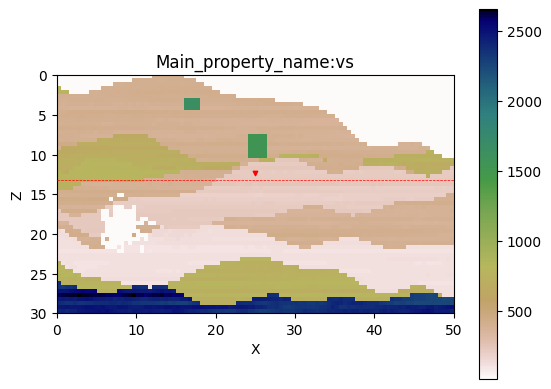

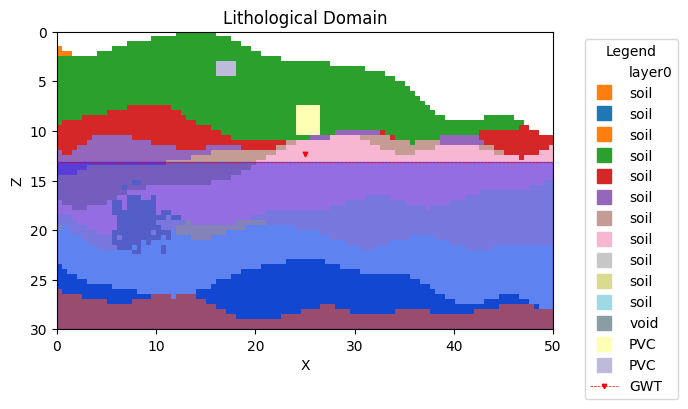

In [41]:
all_profiles[4].merged_generated_model2d.plot_profile('vs')
gen_profiles.merged_generated_model2d.plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

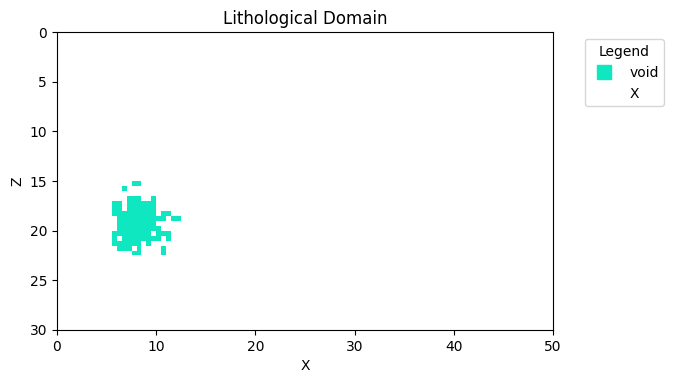

In [42]:
# gen_profiles.generated_model2d_set['soil'].plot_profile('vs')
gen_profiles.generated_model2d_set['karst'].plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')